In [1]:
import numpy as np
import pandas as pd

import utils
from package_name.evaluation import plots as eval_plots
from package_name.evaluation.utils import predict_clusters
from package_name.evaluation import metrics
from package_name.training.trainer import VAETrainer, VAEConfig
from package_name.tuning.cross_validator import CrossValidator
from package_name.inference.predictor import VAEPredictor
from package_name.model.utils import sampling, LossFactorsConfig
from package_name.evaluation.pca_kmeans import PCAKmeansTrainer,  PCAKmeansPredictor


import matplotlib.pyplot as plt
plt.style.use('default')



/home/zilnora/.conda/envs/CodeForEarth/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
I0000 00:00:1787671944.316536 3675666 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787671944.317300 3675666 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787671944.372392 3675666 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787671951.618322 3675666 port.cc:153] oneDNN custom operations are on. You ma

## Parameters

In [2]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
results_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/training_test_split/"
data_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/"
cluster_number = 4
original_dim = 575
pr_cluster_number = 4
batch_size = 128
epochs = 500


## Data loading and pre-processing

In [3]:
# #create clusters for country-wise energy data
# path = data_path + "WON_country_wise.csv"

# df_in = pd.read_csv(path, comment="#")

# df_filtered = df_in.copy()
# df_filtered["Date"] = pd.to_datetime(df_filtered["Date"])
# df_filtered = df_filtered[(df_filtered["Date"].dt.year > 1980) & (df_filtered["Date"].dt.year < 2023)]
# df_filtered = df_filtered[df_filtered["Date"].dt.month.isin(extended_winter_months)]

# df_countries = df_filtered.drop(columns=["Date"])
# df_countries = df_countries.dropna(axis=1, how="all").reset_index(drop=True)

# df_norm, df_clusters = utils.cluster_country_wise(df_countries, cluster_number=pr_cluster_number, standardize=True)

# df_clusters.to_csv(data_path + "WON_clusters_norm.csv")
# df_norm.to_csv(data_path + "WON_country_wise_norm.csv")

df_clusters = pd.read_csv(data_path + "WON_clusters_norm.csv", index_col=0)
df_norm = pd.read_csv(data_path + "WON_country_wise_norm.csv", index_col=0)

In [4]:
# Get training data
z500 = utils.preprocess_dataset(filename = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/z500/era5_z500_daily_250_atlantic_1940_2022.nc",
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = 'extended europe',
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)


# Get training data labels
pr_labels = pd.read_csv(data_path + 'WON_clusters_norm.csv')
pr_labels.columns = ['index', 'labels']
#pr_labels.drop(pr_labels.tail(1).index,inplace=True)

pr_labels['values']=[1]*len(pr_labels)
label_indices_pd = pd.pivot_table(pr_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values



In [5]:
#set training and testing data
training_indices = np.where(z500['time.year'] < 2015)[0]
testing_indices = np.where(z500['time.year'] >= 2015)[0]

z500_training = z500[training_indices]
z500_testing = z500[testing_indices]

z500_reshaped_training = z500_reshaped[training_indices]
z500_reshaped_testing = z500_reshaped[testing_indices]

label_indices_training = label_indices[training_indices]
label_indices_testing = label_indices[testing_indices]

df_norm_training = df_norm.iloc[training_indices]
df_norm_testing = df_norm.iloc[testing_indices]

In [6]:
print("count of each label", label_indices.sum(axis=0)/label_indices.sum())

count of each label [0.23126574 0.38617758 0.16813602 0.21442065]


## Visualise target clusters

In [34]:
utils.plot_country_wise_cluster_means(country_data=df_norm, cluster_labels=df_clusters)

## Define model

In [6]:
config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,#8,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

loss_config = LossFactorsConfig(
    vae_reconstruction_loss_factor=1,
    vae_regularisation_loss_factor=1,
    target_prediction_loss_factor=1,
    cluster_target_regularisation_loss_factor=1,#5
    mixture_regularization_loss_factor=1,#2,
    dirichlet_loss_factor=0.5 #1
)

vae = VAETrainer(cfg=config,  path_to_save_weights=results_path, loss_factors=loss_config)
vae.compile()

history = vae.fit(
    X=z500_training.values,
    y=label_indices_training,
    epochs=epochs,
    batch_size=batch_size
)

vae.save_weights(results_path+'final_weights_'+str(cluster_number)+'_4_5_training_test.weights.h5')

E0000 00:00:1786027821.436688  366070 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/500


KeyboardInterrupt: 

## Plot training and validation losses

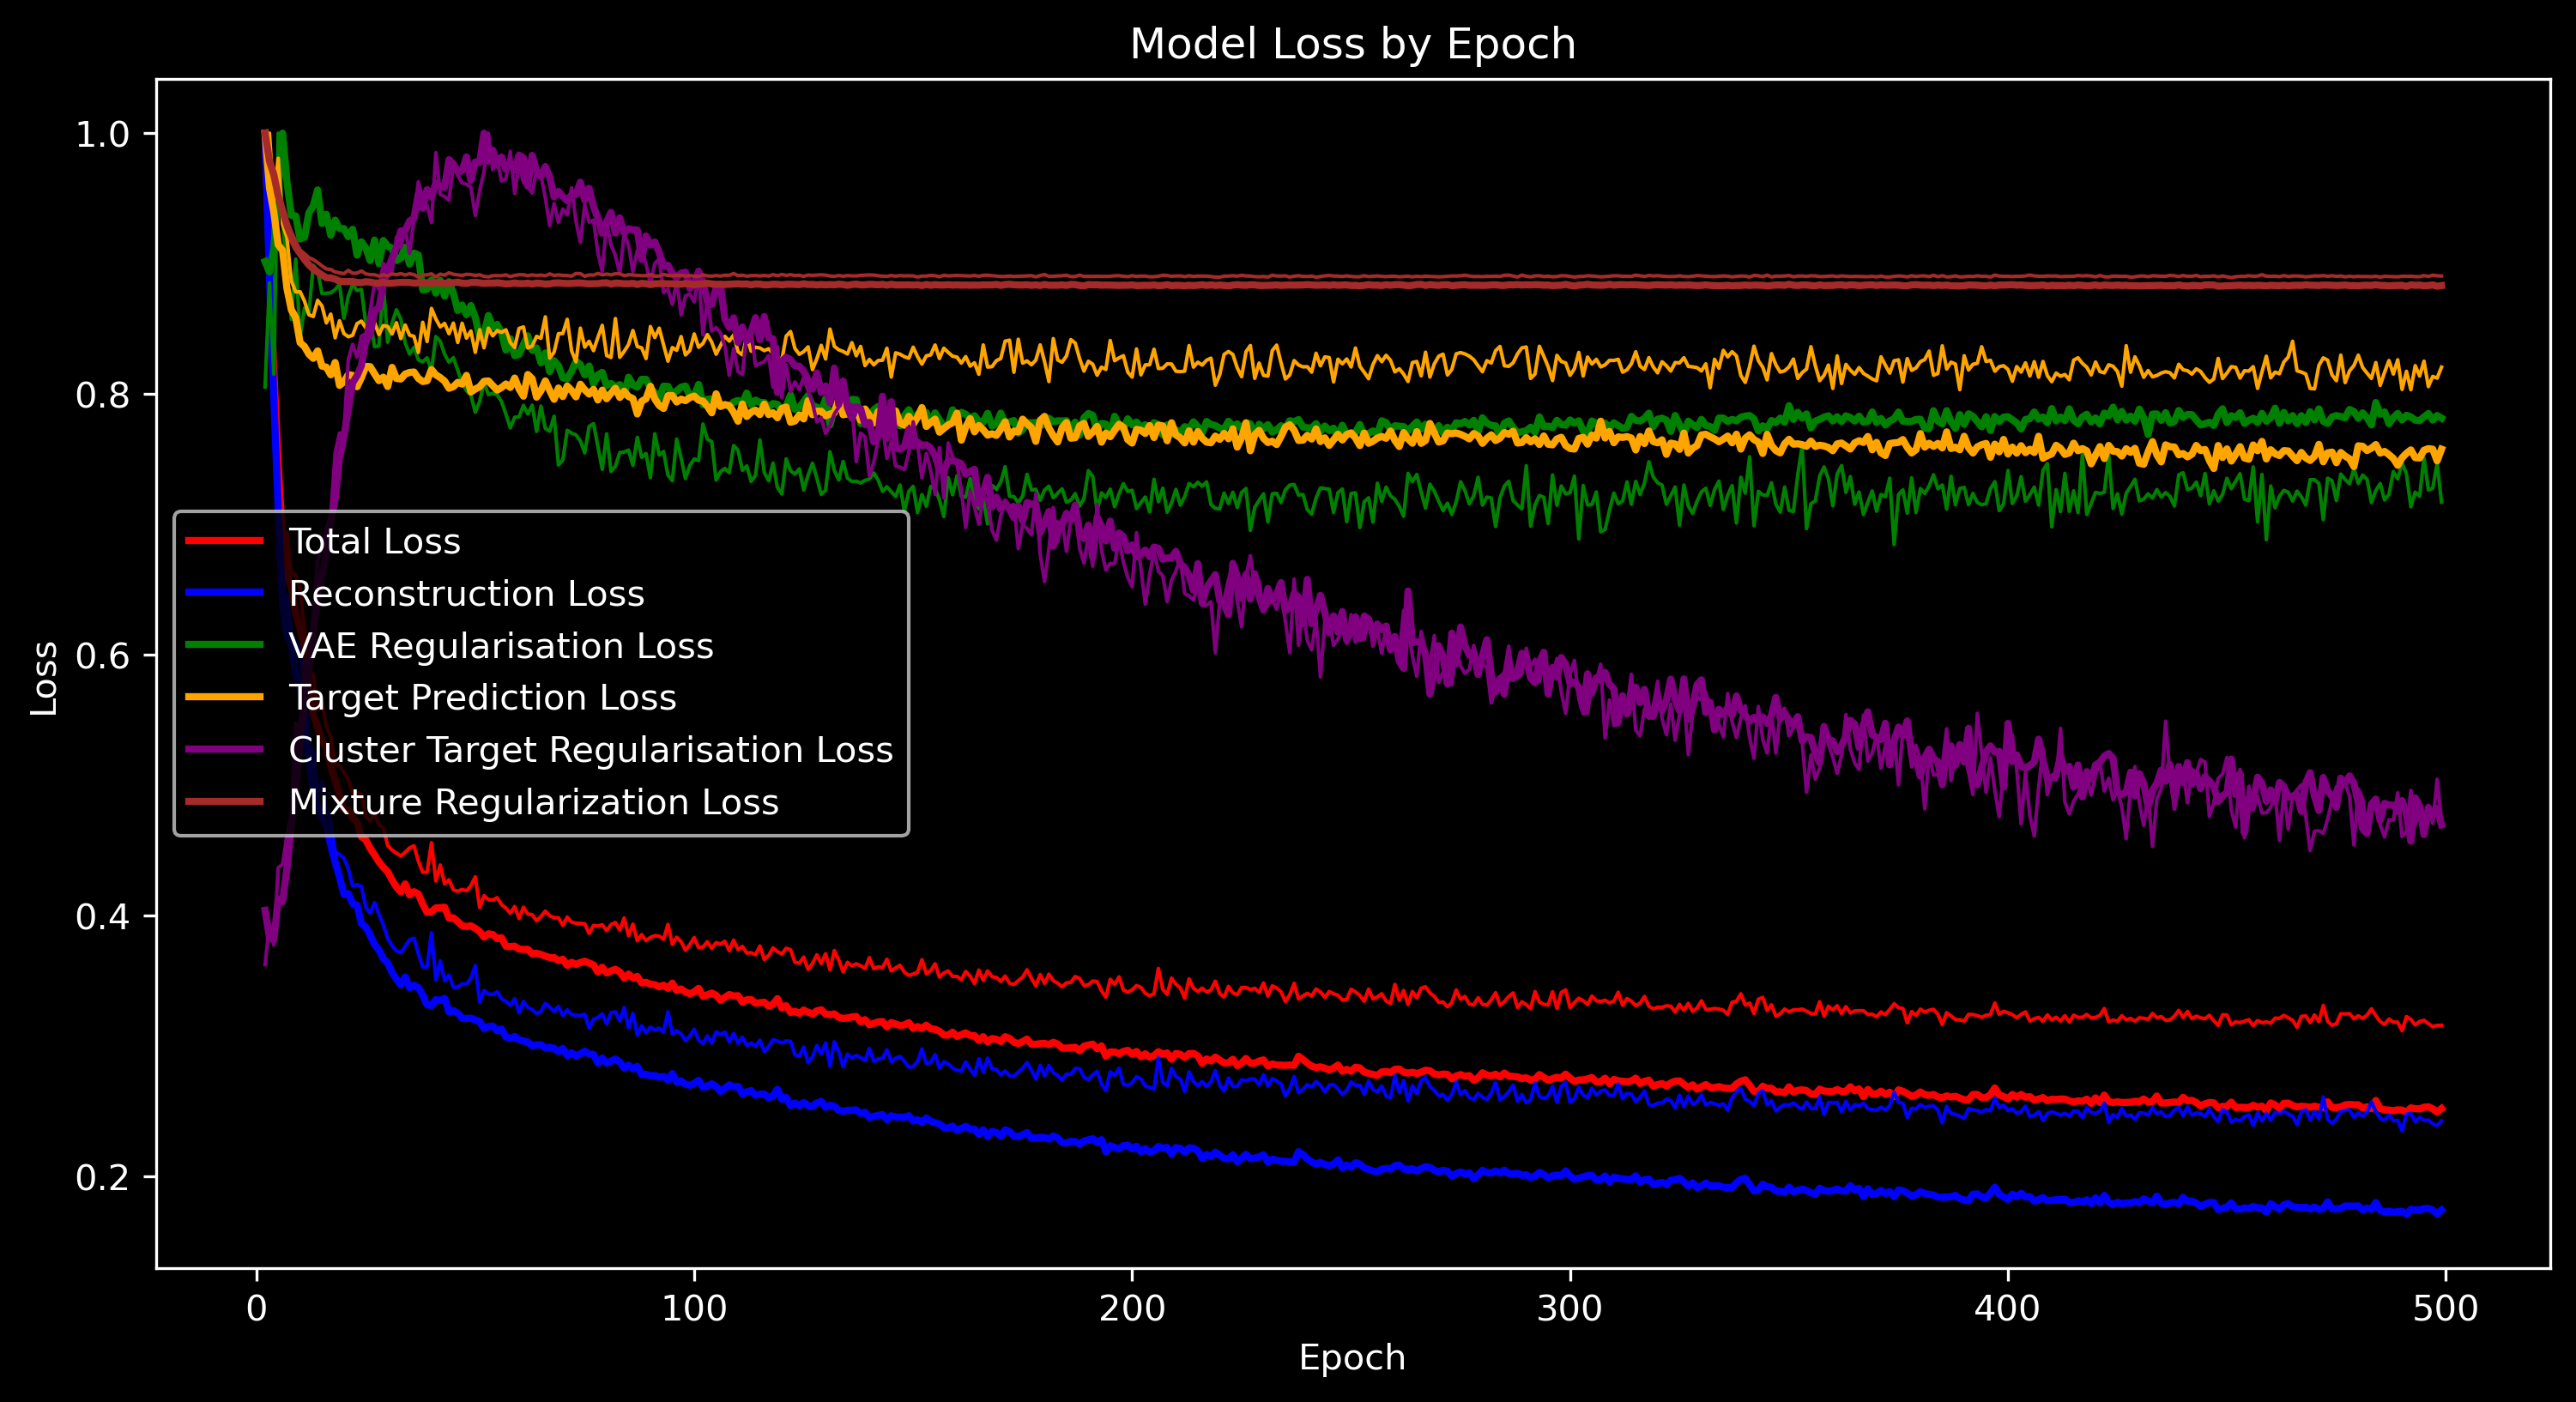

In [51]:
utils.plot_all_losses(history=history)

## Cross validation

In [52]:
cross_validator = CrossValidator(vae=vae,filepath=results_path,cluster_number=cluster_number,n_runs=10)
histories = cross_validator.run(X=z500_training.values,y=label_indices_training,epochs=epochs, batch_size=batch_size)

Epoch 1/500
 5/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - cluster_target_regularisation_loss: 0.2296 - mixture_regularization_loss: 3.7931 - reconstruction_loss: 575.6450 - target_prediction_loss: 6.6410 - total_loss: 594.4728 - vae_regularisation_loss: 8.1642 

10/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - cluster_target_regularisation_loss: 0.1853 - mixture_regularization_loss: 3.7133 - reconstruction_loss: 578.2624 - target_prediction_loss: 6.3928 - total_loss: 594.9443 - vae_regularisation_loss: 6.3905

/home/zilnora/.conda/envs/CodeForEarth/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 56 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - cluster_target_regularisation_loss: 0.2164 - mixture_regularization_loss: 3.3245 - reconstruction_loss: 513.5637 - target_prediction_loss: 5.9799 - total_loss: 533.3693 - vae_regularisation_loss: 10.2847 - val_cluster_target_regularisation_loss: 0.4676 - val_mixture_regularization_loss: 3.0587 - val_reconstruction_loss: 351.0237 - val_target_prediction_loss: 6.3800 - val_total_loss: 384.1212 - val_vae_regularisation_loss: 23.1912
Epoch 2/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - cluster_target_regularisation_loss: 0.4739 - mixture_regularization_loss: 2.9633 - reconstruction_loss: 272.7065 - target_prediction_loss: 6.4571 - total_loss: 306.1492 - vae_regularisation_loss: 23.5485 - val_cluster_target_regularisation_loss: 0.4288 - val_mixture_regularization_loss: 2.9058 - val_reconstruction_loss: 245.8583 - val_target_prediction_loss: 6.0162 - val_total_loss: 276.6445 - val_vae_regularisation_loss: 21.4355
Epoch 3/500
29/29 ━━━━━━━━━━━━━━━━━━

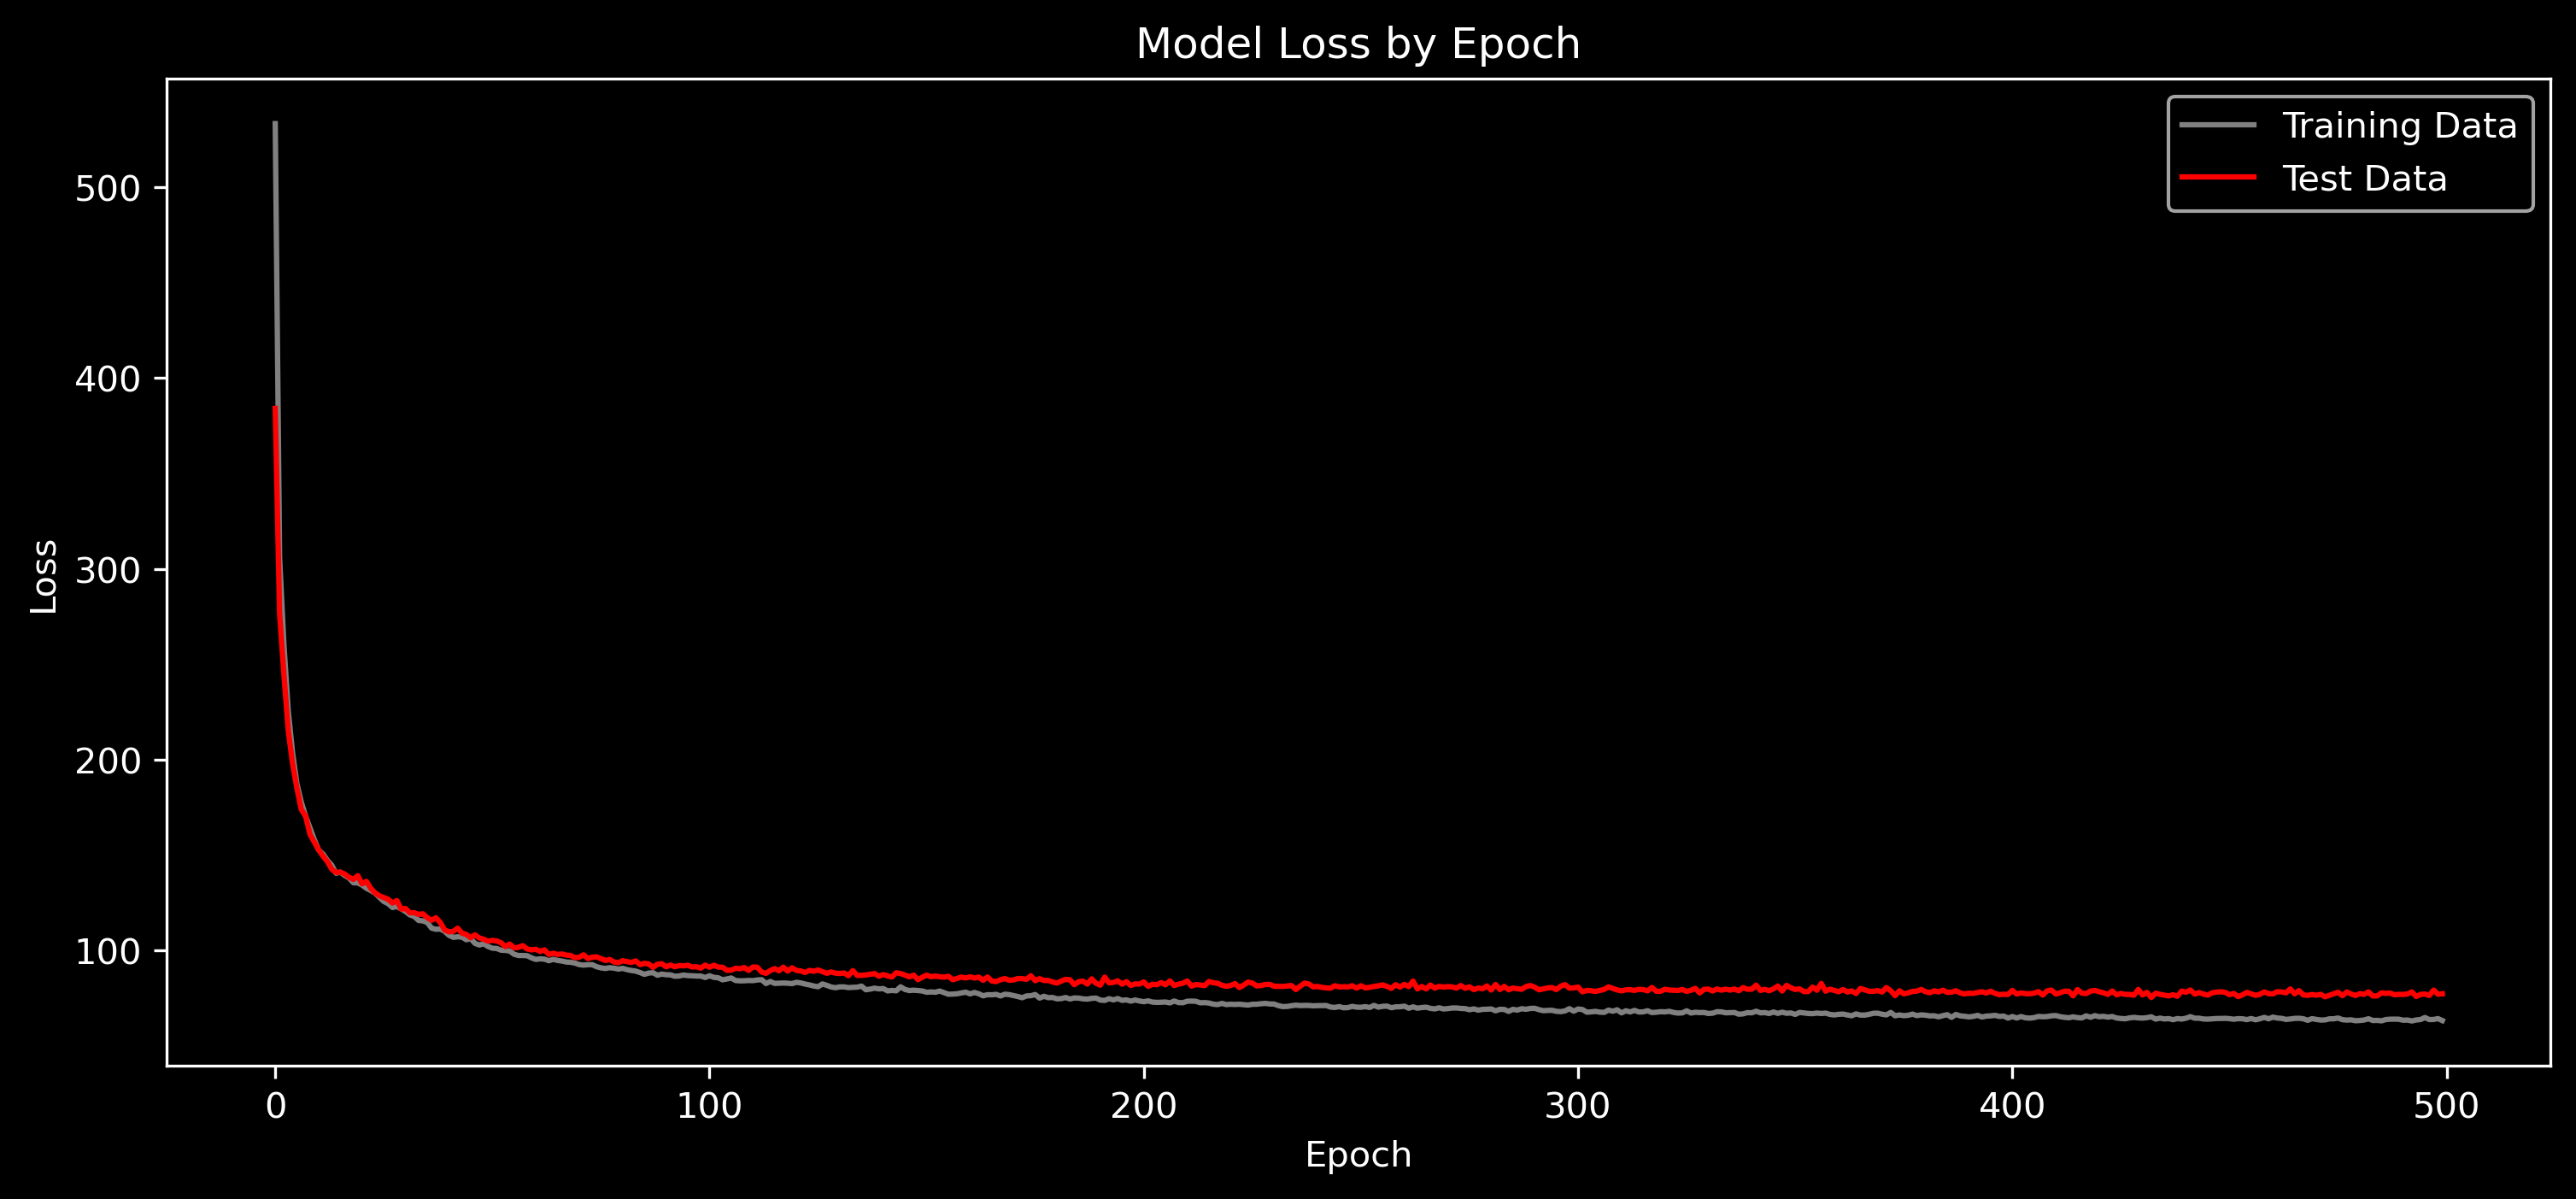

In [64]:
number = 0

training_loss = histories[number].history['total_loss']
validation_loss = histories[number].history['val_total_loss']
utils.plot_losses(training_loss, validation_loss)

## Visualize clusters centers & target maps

In [6]:
cluster_number = 4

config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

In [7]:
def plot_run(run_id: int):
    """
    Plot mixture component centers, empirical cluster centers, and target variable for empirical cluster centers

    :param run_id: The ID of the run to plot
    """
    vae = VAEPredictor(cfg=config)
    weights_path = results_path + f"final_weights_{vae.cfg.cluster_number}_{run_id}.weights.h5"
    vae.load_weights(weights_path)

    cluster_probabilities = predict_clusters(vae=vae, inputs=z500_training.values)
    cluster_labels = np.argmax(cluster_probabilities, axis=1)
    z500_with_label = z500_training.assign_coords(cluster=("time", cluster_labels))

    #order clusters by how often they occur in the data
    label_counts = np.bincount(z500_with_label.cluster.values)
    label_order = np.argsort(label_counts)[::-1]  # Sort in descending order

    #call plotting functions
    fig_cluster_centers = eval_plots.plot_cluster_centers(
        vae,
        z500[0],
        #plot_reordering=label_order,
        levels=np.arange(-2.0, 2.1, 0.25),
    )

    fig_empirical_cluster_centers = eval_plots.plot_empirical_cluster_centers(
        z500_with_label,
        #plot_reordering=label_order,
        levels=np.arange(-2.0, 2.1, 0.25),
    )

    column_labels = df_norm_training.columns.astype(str).tolist()

    cluster_label_df = pd.DataFrame({'labels':cluster_labels})
    utils.plot_country_wise_cluster_means(country_data=df_norm_training, cluster_labels=cluster_label_df)

E0000 00:00:1786028400.741339  375501 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


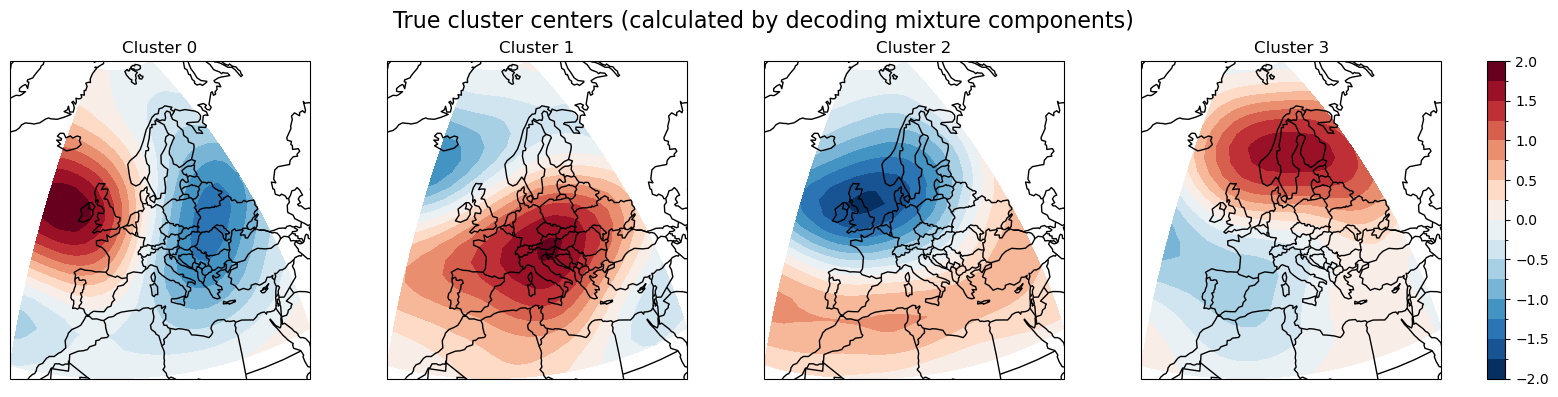

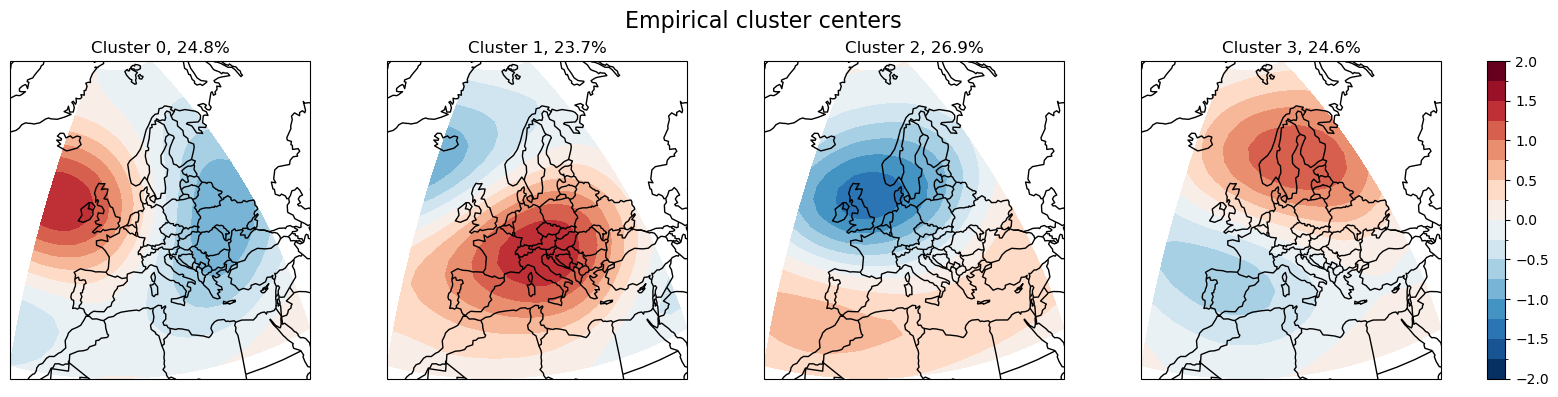

In [8]:
plot_run(run_id=4)

## Informativeness metrics

In [12]:
def get_skill_scores(metric_func: callable, n_runs: int) -> np.ndarray:
    """Compute skill scores for various versions of the target variable.

    :param metric_func: Function to compute a skill score. It should take a VAEPredictor as input and return a float.
    :param n_runs: Number of runs to compute the skill scores for.
    :return: Array of Brier skill scores for each run.
    """
    vae = VAEPredictor(cfg=config)
    scores = []
    for run_id in range(n_runs):
        vae.load_weights(results_path + f"final_weights_{vae.cfg.cluster_number}_{run_id}.weights.h5")
        bss = metric_func(vae)
        scores.append(bss)
    return np.array(scores)

def get_skill_scores_for_all_metrics(n_runs: int = 10) -> np.ndarray:
    """Compute the Brier skill scores for precipitation clusters, 5th percentile exceedance, and precipitation terciles.

    :param n_runs: Number of runs to compute the skill scores for.
    :return: Array of Brier skill scores for each metric and each run.
    """
    metric_funcs = [lambda vae: metrics.compute_BSS_clusters_target(vae, z500_testing.values, label_indices_testing),
                    lambda vae: metrics.compute_BSS_quantile_exceedance(vae, z500_testing.values, df_norm_testing.values, q = 0.1, larger_than=False),
                    #lambda vae: metrics.compute_BSS_quantile_prediction(vae, z500_testing.values, df_norm_testing.values, N = 3)
                    ]
    
    metric_names = ["Brier skill score\nfor wind energy clusters",
                     "Brier skill score\nfor being lower than 5th\npercentile per grid point",
                     #"Brier skill score\nfor terciles per grid point"
                     ]
    
    n_metrics = len(metric_funcs)
    scores = np.zeros((n_metrics, n_runs))

    for metric_id in range(n_metrics):
        scores[metric_id] = get_skill_scores(metric_funcs[metric_id], n_runs)

    return scores, metric_names


In [13]:
scores, metric_names = get_skill_scores_for_all_metrics()

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


### Get clusters with PCA + k-means

In [9]:


X_train = z500_reshaped_training
X_test = z500_reshaped_testing

pca_kmeans_trainer = PCAKmeansTrainer(n_clusters=cluster_number, n_components=15, model_dir="/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/PCA/")

cluster_probs_train, info = pca_kmeans_trainer.cluster(x=X_train)
pca_kmeans_trainer.save_models(info)


pca_kmeans_predictor = PCAKmeansPredictor(model_dir="/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/PCA/")
cluster_probs_test = pca_kmeans_predictor.clusters(x=X_test)


In [10]:
scores_pca = np.zeros((2, 1))
scores_pca[0] = metrics.compute_BSS_clusters_target_pca(pca_kmeans_predictor, X_test, label_indices_testing)
#scores_pca[2] = metrics.compute_BSS_quantile_prediction_pca(pca_kmeans_predictor, X_test, df_norm_testing.values, N = 3)
scores_pca[1] = metrics.compute_BSS_quantile_exceedance_pca(pca_kmeans_predictor, X_test, df_norm_testing.values, q=0.1, larger_than=False)

### Plot scores

(0.0, 0.25)

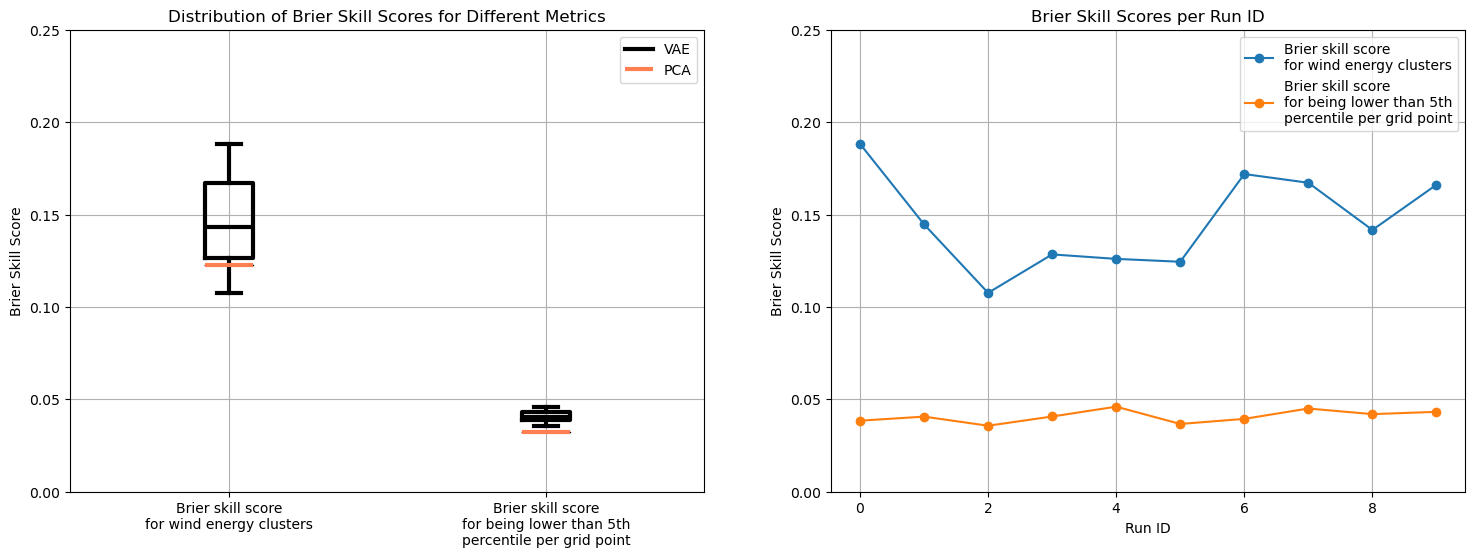

In [15]:
_, axs = plt.subplots(1, 2, figsize=(18, 6))

# Box and whisker plots
ax = axs[0]
props = dict(linewidth=3, color='k')
vae_box = ax.boxplot(
    scores.T, 
    boxprops=props, 
    medianprops=props,
    whiskerprops=props,  # Thicker vertical lines
    capprops=props,       # Thicker horizontal end caps
)


# add pca line in red
props = dict(linewidth=3, color='coral')
pca_box = ax.boxplot(
    scores_pca.reshape(-1, 1).T,
    medianprops=props,
)

ax.set_xticks(range(1, len(metric_names) + 1))
ax.set_xticklabels(metric_names, rotation=0, ha='center')
ax.legend([vae_box["boxes"][0], pca_box["medians"][0]], ["VAE", "PCA"], loc="upper right")
ax.set_title("Distribution of Brier Skill Scores for Different Metrics")
ax.set_ylabel("Brier Skill Score")
ax.set_ylim(0,0.25)
ax.grid()

# plots per run id
ax = axs[1]
for metric_id in range(scores.shape[0]):
    ax.plot(range(scores.shape[1]), scores[metric_id], marker='o', label=metric_names[metric_id])
ax.set_title("Brier Skill Scores per Run ID")
ax.set_xlabel("Run ID")
ax.set_ylabel("Brier Skill Score")
ax.grid()
ax.legend()
ax.set_ylim(0,0.25)